In [1]:
import pickle
import tensorflow as tf
from livelossplot import PlotLossesKeras

In [2]:
with open('data_train', 'rb') as f:
    df = pickle.load(f)

In [3]:
import matplotlib.pyplot as plt
import numpy as np

arr = df['images'].astype('int')

In [4]:
arr

array([[[[ 21,  27,  49],
         [ 18,  20,  44],
         [ 13,  13,  41],
         ...,
         [  0,   4,   6],
         [  0,   4,   4],
         [  0,   4,   3]],

        [[ 28,  36,  56],
         [ 26,  32,  56],
         [ 21,  25,  52],
         ...,
         [  1,   5,   8],
         [  0,   4,   4],
         [  0,   3,   2]],

        [[ 55,  64,  80],
         [ 54,  61,  81],
         [ 48,  54,  77],
         ...,
         [  1,   5,   8],
         [  0,   4,   5],
         [  1,   5,   4]],

        ...,

        [[ 55,  47,  57],
         [ 36,  31,  40],
         [ 19,  16,  24],
         ...,
         [  7,   8,   8],
         [  7,   9,   8],
         [  7,   8,   8]],

        [[ 18,   8,  22],
         [ 14,   7,  20],
         [  8,   4,  14],
         ...,
         [  8,   8,   7],
         [  8,   8,   8],
         [  7,   7,   7]],

        [[ 13,   5,  20],
         [ 14,   7,  20],
         [ 15,  11,  21],
         ...,
         [  9,   9,   9],
        

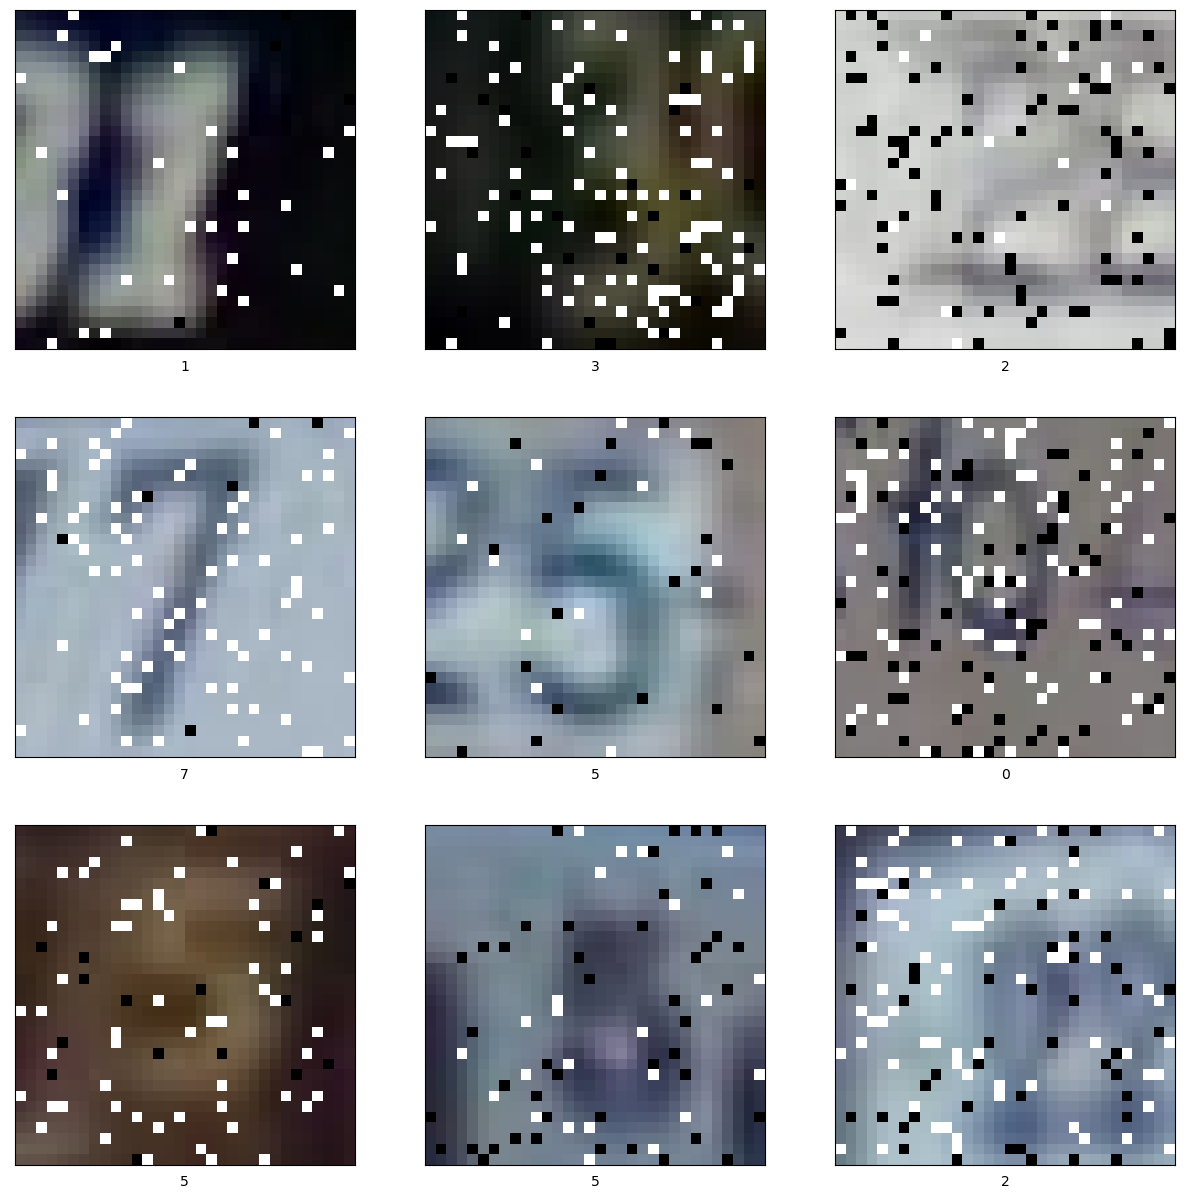

In [5]:
plt.figure(figsize=(15,15))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(np.array(arr[i]))
    plt.xlabel(df['labels'][i])
plt.show()

In [6]:
from statistics import mean
for i, j in enumerate(arr):
    for ii, jj in enumerate(j):
        for iii, jjj in enumerate(jj):
            if list(jjj) in [[0, 0, 0], [255, 255, 255]]:
                for k in range(3):
                    try:
                        arr[i, ii, iii, k] = mean([arr[i, ii, iii + 1, k],
                                               arr[i, ii, iii - 1, k],
                                               arr[i, ii + 1, iii - 1, k],
                                               arr[i, ii + 1, iii + 1, k],
                                               arr[i, ii - 1, iii + 1, k],
                                               arr[i, ii - 1, iii - 1, k]])
                    except IndexError:
                        pass


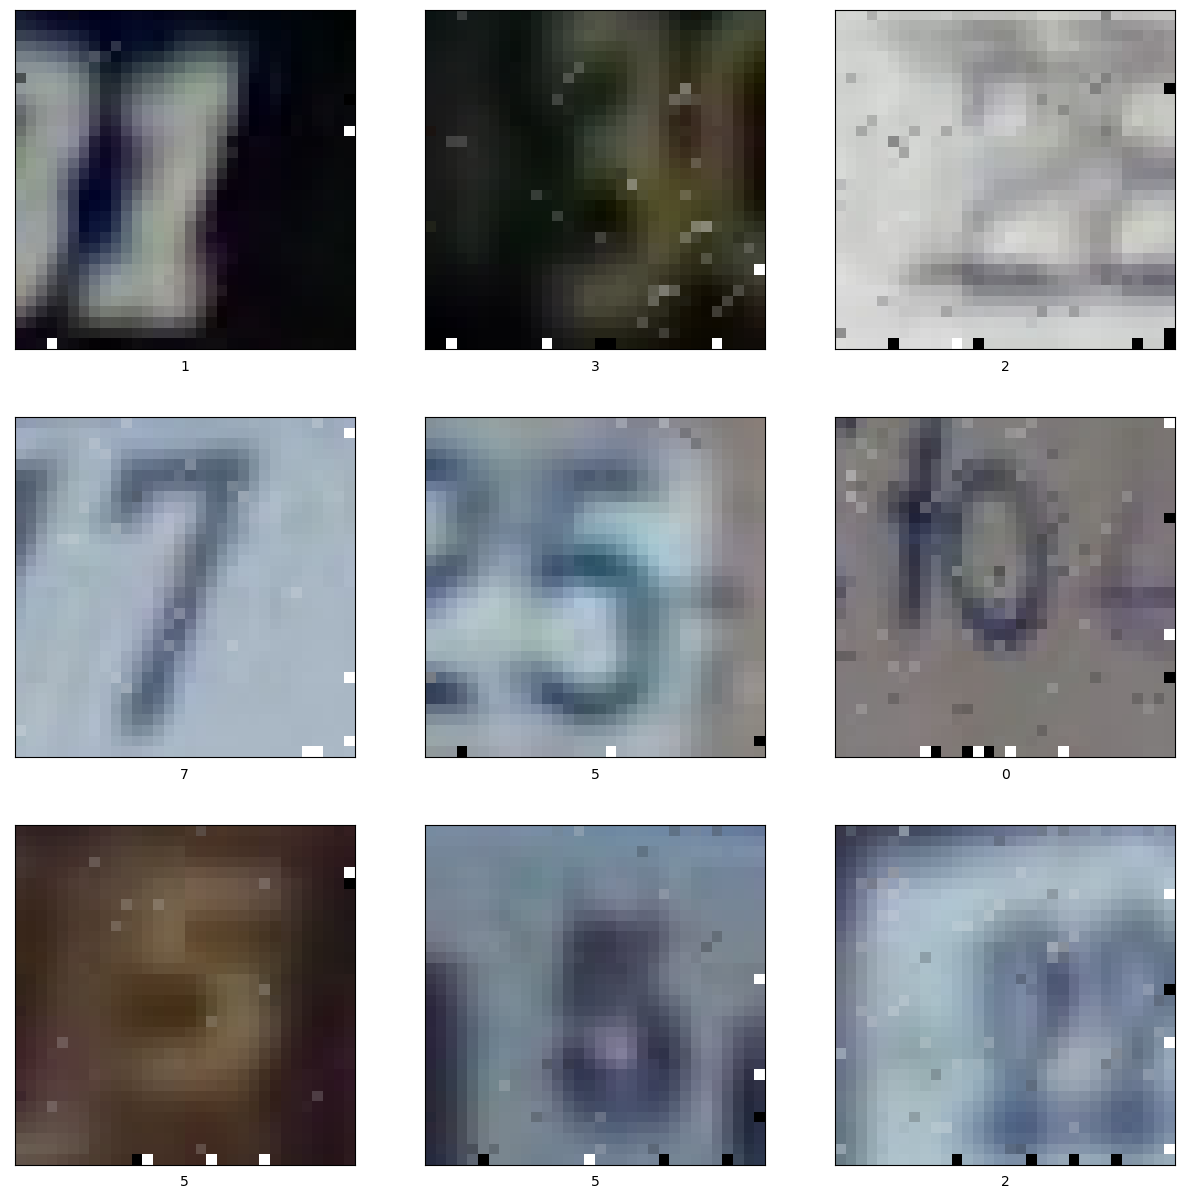

In [7]:
plt.figure(figsize=(15,15))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(np.array(arr[i]))
    plt.xlabel(df['labels'][i])
plt.show()

In [8]:
arr = arr / 255.

In [9]:
from sklearn.model_selection import train_test_split

train_images, validation_images, train_labels, validation_labels = train_test_split(arr, df['labels'], test_size=0.01)

In [10]:
train_images.shape

(49500, 32, 32, 3)

In [11]:
train_dataset = tf.data.Dataset.from_tensor_slices((train_images,
                                                    train_labels))

val_dataset = tf.data.Dataset.from_tensor_slices((validation_images,
                                                  validation_labels))

Metal device set to: Apple M1


2022-12-05 15:35:47.222258: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2022-12-05 15:35:47.222382: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [12]:
input_shape = train_images.shape[-3:]
input_shape

(32, 32, 3)

In [13]:
batch_size = 256
train_dataset = train_dataset.shuffle(buffer_size = 1024, reshuffle_each_iteration=True)
train_dataset = train_dataset.batch(batch_size)

val_dataset = val_dataset.batch(batch_size)

In [14]:
input_layer = tf.keras.layers.Input(shape=input_shape)

# Первый блок:
b1l1 = tf.keras.layers.Conv2D(32, 3, activation="relu", padding="same")(input_layer)
b1l2 = tf.keras.layers.Conv2D(64, 3, activation="relu", padding="same")(b1l1)
b1_output = tf.keras.layers.MaxPooling2D()(b1l2)

# Второй блок:
b2l1 = tf.keras.layers.Conv2D(64, 3, activation="relu", padding="same")(b1_output)
b2l2 = tf.keras.layers.Conv2D(64, 3, activation="relu", padding="same")(b2l1)

# Связываем эти 2 блока
b2b1_output = tf.keras.layers.add([b2l2, b1_output])

# Третий блок:
b3l1 = tf.keras.layers.Conv2D(64, 3, activation="relu", padding="same")(b2b1_output)
b3l2 = tf.keras.layers.Conv2D(64, 3, activation="relu", padding="same")(b3l1)

# Связываем эти 2 блока
block_3_output = tf.keras.layers.add([b3l2, b2b1_output])

l1 = tf.keras.layers.Conv2D(64, 3, activation="relu", padding="same")(block_3_output)
l2 = tf.keras.layers.GlobalAveragePooling2D()(l1)
l3 = tf.keras.layers.Dense(256, activation="relu")(l2)
l4 = tf.keras.layers.Dropout(.5)(l3)
outputs = tf.keras.layers.Dense(10)(l4)

In [15]:
model_resnet = tf.keras.Model(input_layer, outputs, name="resnet")

In [16]:
model_resnet.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy'])
model_resnet.summary()

Model: "resnet"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 32, 32, 3)]  0           []                               
                                                                                                  
 conv2d (Conv2D)                (None, 32, 32, 32)   896         ['input_1[0][0]']                
                                                                                                  
 conv2d_1 (Conv2D)              (None, 32, 32, 64)   18496       ['conv2d[0][0]']                 
                                                                                                  
 max_pooling2d (MaxPooling2D)   (None, 16, 16, 64)   0           ['conv2d_1[0][0]']               
                                                                                             

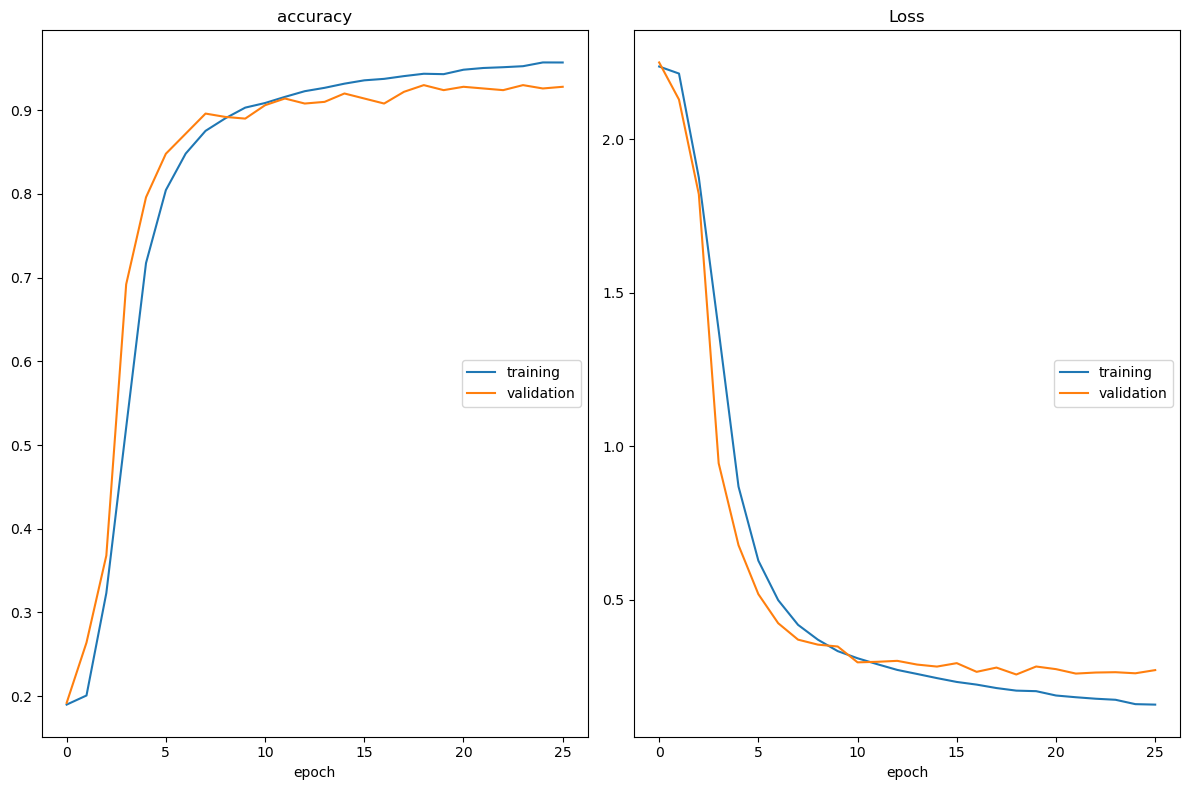

accuracy
	training         	 (min:    0.190, max:    0.957, cur:    0.957)
	validation       	 (min:    0.192, max:    0.930, cur:    0.928)
Loss
	training         	 (min:    0.157, max:    2.238, cur:    0.157)
	validation       	 (min:    0.256, max:    2.251, cur:    0.270)


In [17]:
model_resnethist = model_resnet.fit(train_dataset, validation_data=val_dataset, epochs=26, callbacks=[PlotLossesKeras()], verbose=False)

In [30]:
with open('data_test', 'rb') as f:
    test_data = pickle.load(f)
arrtest =  test_data['images'].astype('int')
for i, j in enumerate(arrtest):
    for ii, jj in enumerate(j):
        for iii, jjj in enumerate(jj):
            if list(jjj) in [[0, 0, 0], [255, 255, 255]]:
                for k in range(3):
                    try:
                        arrtest[i, ii, iii, k] = mean([arrtest[i, ii, iii + 1, k],
                                                   arrtest[i, ii, iii - 1, k],
                                                   arrtest[i, ii + 1, iii - 1, k],
                                                   arrtest[i, ii + 1, iii + 1, k],
                                                   arrtest[i, ii - 1, iii + 1, k],
                                                   arrtest[i, ii - 1, iii - 1, k]])
                    except IndexError:
                        pass

arrtest = arrtest / 255.

In [31]:
predictions = model_resnet.predict(arrtest)
predictions


782/782 [==============================] - 5s 7ms/step


array([[-6.9644938 , -0.34578907, -6.1088424 , ..., -2.8603778 ,
        -4.820605  ,  0.12733234],
       [-5.8615966 ,  1.8275065 , -4.2014265 , ..., -6.1554155 ,
        -1.20914   , -0.3190955 ],
       [-1.6056066 ,  8.495921  , -3.7555606 , ...,  3.710238  ,
        -3.5470903 , -4.247977  ],
       ...,
       [ 9.866691  , -0.9453946 , -1.4246047 , ..., -1.8299891 ,
        -2.3478556 , -0.7990397 ],
       [-3.8798666 , -4.2053766 , -4.0126095 , ..., -5.8391314 ,
        -0.32257673, 10.887819  ],
       [-4.802162  , -0.12642913,  8.438083  , ..., -0.80443776,
        -2.6451714 , -6.0416923 ]], dtype=float32)

In [32]:
classes = np.argmax(predictions, axis=1)
classes

array([5, 4, 1, ..., 0, 9, 2])

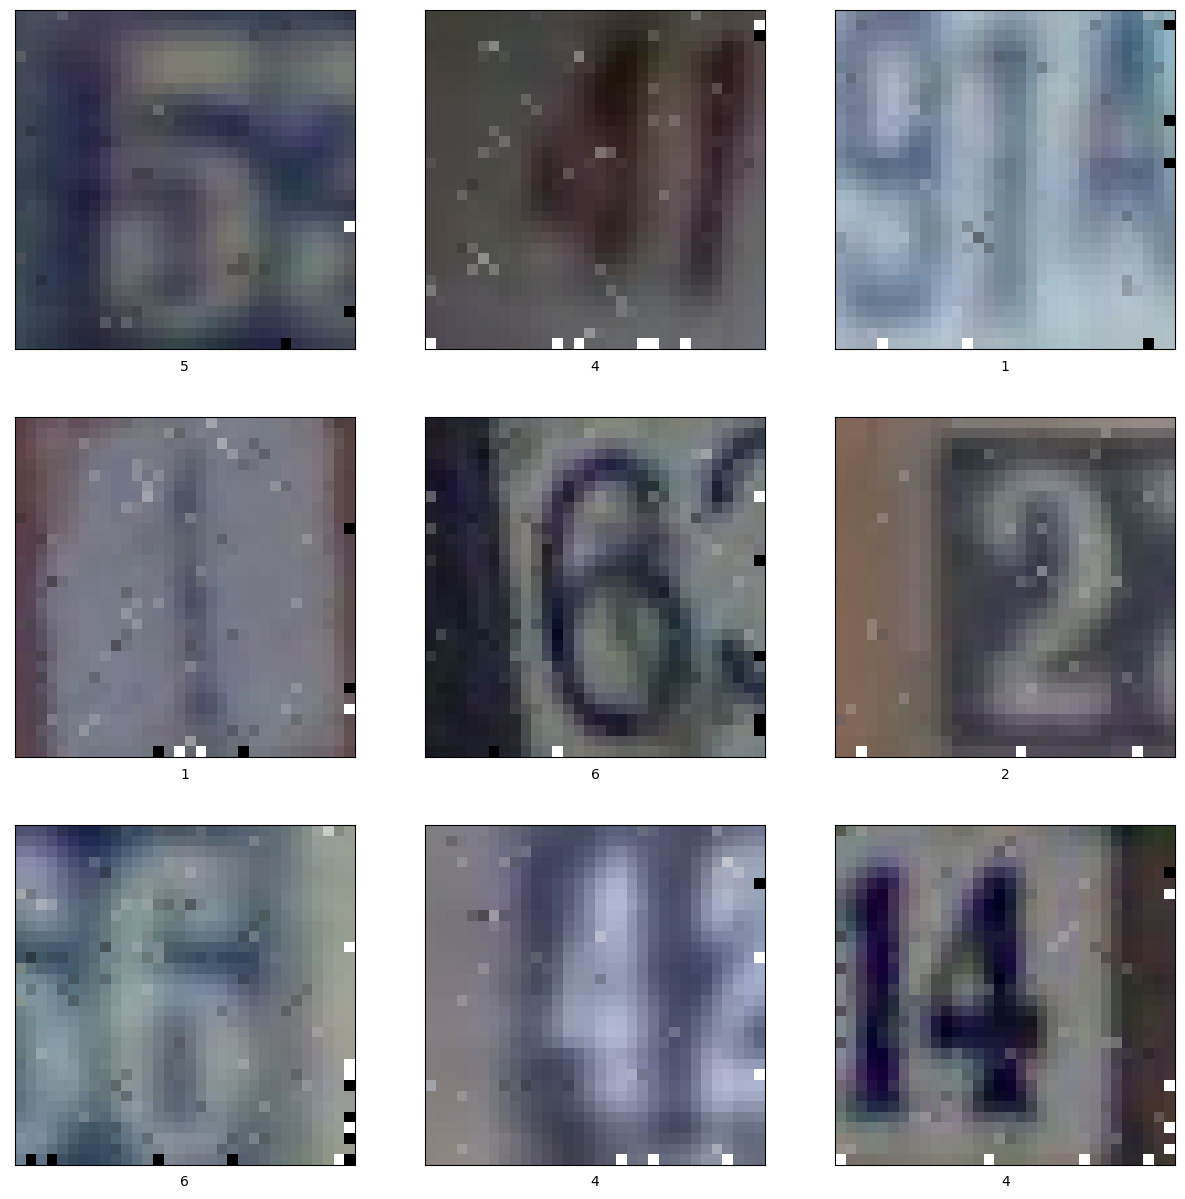

In [33]:
plt.figure(figsize=(15,15))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(np.array(arrtest[i]))
    plt.xlabel(classes[i])
plt.show()

In [49]:
with open('submission.csv', 'w') as f:
    f.write('Id,Category\n')
    for i, j in enumerate(classes):
        f.write(f'{i},{j}\n')

13